In [1]:
!pip install torchcam

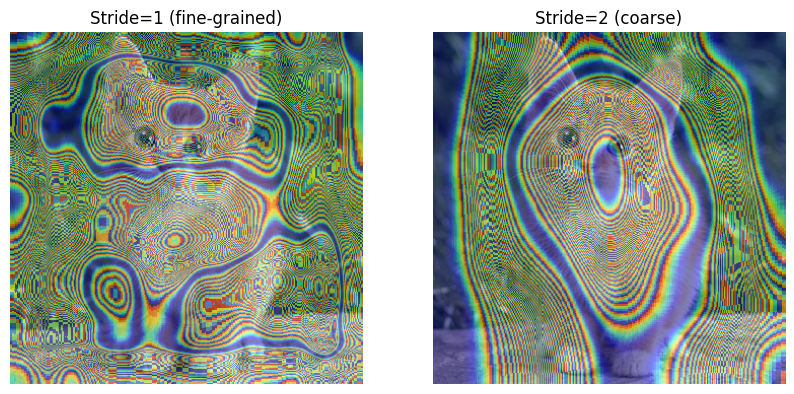

In [9]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import requests


# --------------------------------------------------
# 1️⃣ 두 모델 정의 (stride=1 vs stride=2)
# --------------------------------------------------
def get_resnet(stride_1=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if stride_1:
        model.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
    model.eval()
    return model

model_stride1 = get_resnet(stride_1=True)
model_stride2 = get_resnet(stride_1=False)


# --------------------------------------------------
# 2️⃣ 이미지 불러오기 & 전처리
# --------------------------------------------------
url = "https://pytorch.org/tutorials/_static/img/cat.jpg"  # 아무 이미지로 가능
# url = "https://www.nylabone.com/-/media/project/oneweb/nylabone/images/dog101/10-intelligent-dog-breeds/golden-retriever-tongue-out.jpg?h=430&w=710&hash=7FEB820D235A44B76B271060E03572C7"
img = Image.open(requests.get(url, stream=True).raw).convert('RGB')

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(img).unsqueeze(0)


# --------------------------------------------------
# 3️⃣ Grad-CAM 준비
# --------------------------------------------------
cam_stride1 = GradCAM(model_stride1, target_layer="layer4.1.conv2")
cam_stride2 = GradCAM(model_stride2, target_layer="layer4.1.conv2")

# --------------------------------------------------
# 4️⃣ CAM 계산
# --------------------------------------------------
out1 = model_stride1(input_tensor)
out2 = model_stride2(input_tensor)

idx1 = out1.squeeze(0).argmax().item()
idx2 = out2.squeeze(0).argmax().item()

activation_map_1 = cam_stride1(idx1, scores=out1)[0]
activation_map_2 = cam_stride2(idx2, scores=out2)[0]

# --------------------------------------------------
# 5️⃣ 시각화
# --------------------------------------------------
def visualize_heatmap(img, heatmap, title):
    result = overlay_mask(img, T.ToPILImage()(heatmap), alpha=0.5)
    plt.imshow(result)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
visualize_heatmap(img, activation_map_1, "Stride=1 (fine-grained)")
plt.subplot(1,2,2)
visualize_heatmap(img, activation_map_2, "Stride=2 (coarse)")
plt.show()

In [12]:
model_stride1

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

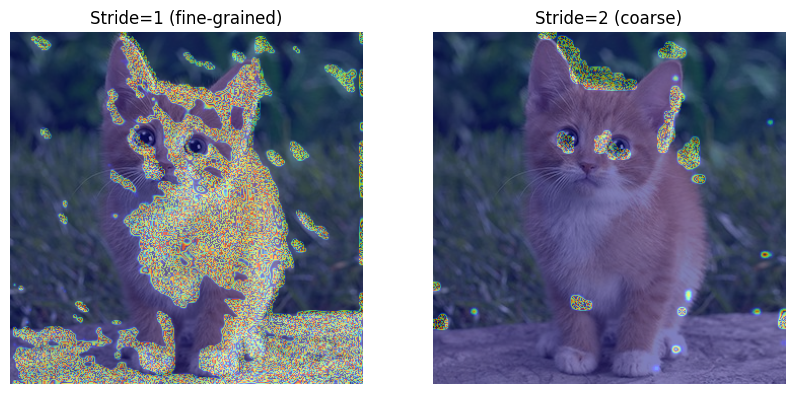

In [20]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import requests


# --------------------------------------------------
# 1️⃣ 두 모델 정의 (stride=1 vs stride=2)
# --------------------------------------------------
def get_resnet(stride_1=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if stride_1:
        model.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
    model.eval()
    return model

model_stride1 = get_resnet(stride_1=True)
model_stride2 = get_resnet(stride_1=False)


# --------------------------------------------------
# 2️⃣ 이미지 불러오기 & 전처리
# --------------------------------------------------
url = "https://pytorch.org/tutorials/_static/img/cat.jpg"  # 아무 이미지로 가능
# url = "https://www.nylabone.com/-/media/project/oneweb/nylabone/images/dog101/10-intelligent-dog-breeds/golden-retriever-tongue-out.jpg?h=430&w=710&hash=7FEB820D235A44B76B271060E03572C7"
img = Image.open(requests.get(url, stream=True).raw).convert('RGB')

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(img).unsqueeze(0)


# --------------------------------------------------
# 3️⃣ Grad-CAM 준비
# --------------------------------------------------
cam_stride1 = GradCAM(model_stride1, target_layer="layer1.0.conv2")
cam_stride2 = GradCAM(model_stride2, target_layer="layer1.0.conv2")

# --------------------------------------------------
# 4️⃣ CAM 계산
# --------------------------------------------------
out1 = model_stride1(input_tensor)
out2 = model_stride2(input_tensor)

idx1 = out1.squeeze(0).argmax().item()
idx2 = out2.squeeze(0).argmax().item()

activation_map_1 = cam_stride1(idx1, scores=out1)[0]
activation_map_2 = cam_stride2(idx2, scores=out2)[0]

# --------------------------------------------------
# 5️⃣ 시각화
# --------------------------------------------------
def visualize_heatmap(img, heatmap, title):
    result = overlay_mask(img, T.ToPILImage()(heatmap), alpha=0.5)
    plt.imshow(result)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
visualize_heatmap(img, activation_map_1, "Stride=1 (fine-grained)")
plt.subplot(1,2,2)
visualize_heatmap(img, activation_map_2, "Stride=2 (coarse)")
plt.show()

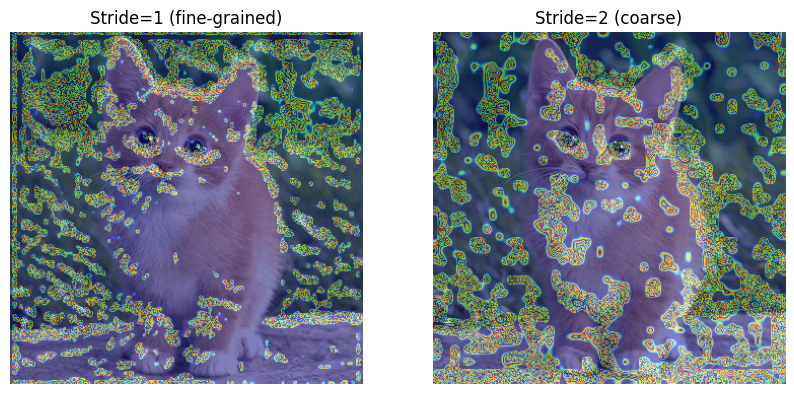

In [21]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import requests


# --------------------------------------------------
# 1️⃣ 두 모델 정의 (stride=1 vs stride=2)
# --------------------------------------------------
def get_resnet(stride_1=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if stride_1:
        model.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
    model.eval()
    return model

model_stride1 = get_resnet(stride_1=True)
model_stride2 = get_resnet(stride_1=False)


# --------------------------------------------------
# 2️⃣ 이미지 불러오기 & 전처리
# --------------------------------------------------
url = "https://pytorch.org/tutorials/_static/img/cat.jpg"  # 아무 이미지로 가능
# url = "https://www.nylabone.com/-/media/project/oneweb/nylabone/images/dog101/10-intelligent-dog-breeds/golden-retriever-tongue-out.jpg?h=430&w=710&hash=7FEB820D235A44B76B271060E03572C7"
img = Image.open(requests.get(url, stream=True).raw).convert('RGB')

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(img).unsqueeze(0)


# --------------------------------------------------
# 3️⃣ Grad-CAM 준비
# --------------------------------------------------
cam_stride1 = GradCAM(model_stride1, target_layer="layer1.1.conv2")
cam_stride2 = GradCAM(model_stride2, target_layer="layer1.1.conv2")

# --------------------------------------------------
# 4️⃣ CAM 계산
# --------------------------------------------------
out1 = model_stride1(input_tensor)
out2 = model_stride2(input_tensor)

idx1 = out1.squeeze(0).argmax().item()
idx2 = out2.squeeze(0).argmax().item()

activation_map_1 = cam_stride1(idx1, scores=out1)[0]
activation_map_2 = cam_stride2(idx2, scores=out2)[0]

# --------------------------------------------------
# 5️⃣ 시각화
# --------------------------------------------------
def visualize_heatmap(img, heatmap, title):
    result = overlay_mask(img, T.ToPILImage()(heatmap), alpha=0.5)
    plt.imshow(result)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
visualize_heatmap(img, activation_map_1, "Stride=1 (fine-grained)")
plt.subplot(1,2,2)
visualize_heatmap(img, activation_map_2, "Stride=2 (coarse)")
plt.show()

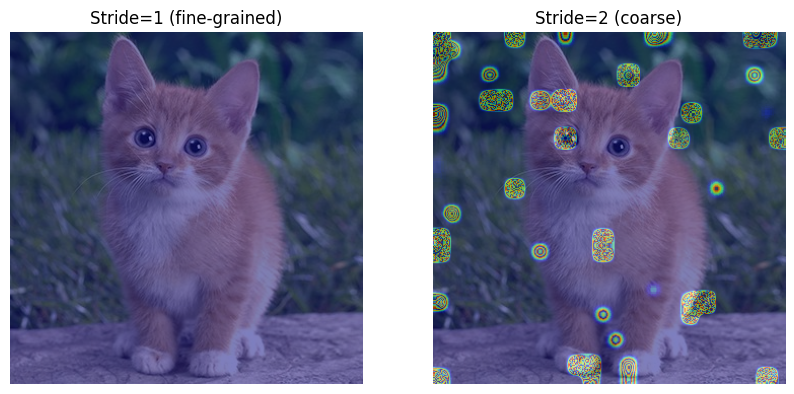

In [14]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import requests


# --------------------------------------------------
# 1️⃣ 두 모델 정의 (stride=1 vs stride=2)
# --------------------------------------------------
def get_resnet(stride_1=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if stride_1:
        model.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
    model.eval()
    return model

model_stride1 = get_resnet(stride_1=True)
model_stride2 = get_resnet(stride_1=False)


# --------------------------------------------------
# 2️⃣ 이미지 불러오기 & 전처리
# --------------------------------------------------
url = "https://pytorch.org/tutorials/_static/img/cat.jpg"  # 아무 이미지로 가능
# url = "https://www.nylabone.com/-/media/project/oneweb/nylabone/images/dog101/10-intelligent-dog-breeds/golden-retriever-tongue-out.jpg?h=430&w=710&hash=7FEB820D235A44B76B271060E03572C7"
img = Image.open(requests.get(url, stream=True).raw).convert('RGB')

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(img).unsqueeze(0)


# --------------------------------------------------
# 3️⃣ Grad-CAM 준비
# --------------------------------------------------
cam_stride1 = GradCAM(model_stride1, target_layer="layer2.0.conv2")
cam_stride2 = GradCAM(model_stride2, target_layer="layer2.0.conv2")

# --------------------------------------------------
# 4️⃣ CAM 계산
# --------------------------------------------------
out1 = model_stride1(input_tensor)
out2 = model_stride2(input_tensor)

idx1 = out1.squeeze(0).argmax().item()
idx2 = out2.squeeze(0).argmax().item()

activation_map_1 = cam_stride1(idx1, scores=out1)[0]
activation_map_2 = cam_stride2(idx2, scores=out2)[0]

# --------------------------------------------------
# 5️⃣ 시각화
# --------------------------------------------------
def visualize_heatmap(img, heatmap, title):
    result = overlay_mask(img, T.ToPILImage()(heatmap), alpha=0.5)
    plt.imshow(result)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
visualize_heatmap(img, activation_map_1, "Stride=1 (fine-grained)")
plt.subplot(1,2,2)
visualize_heatmap(img, activation_map_2, "Stride=2 (coarse)")
plt.show()

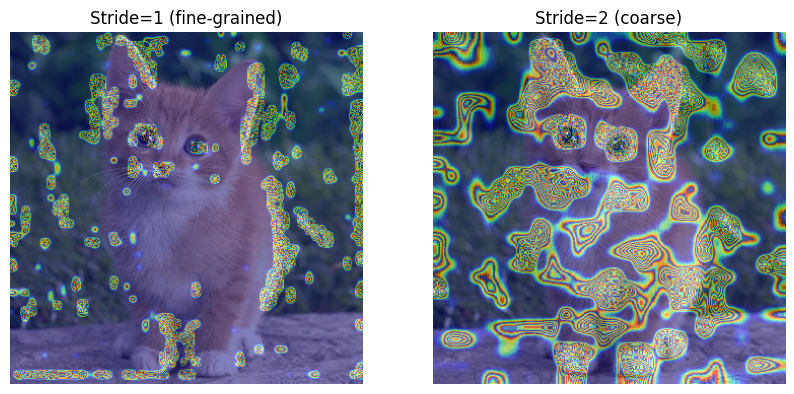

In [10]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import requests


# --------------------------------------------------
# 1️⃣ 두 모델 정의 (stride=1 vs stride=2)
# --------------------------------------------------
def get_resnet(stride_1=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if stride_1:
        model.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
    model.eval()
    return model

model_stride1 = get_resnet(stride_1=True)
model_stride2 = get_resnet(stride_1=False)


# --------------------------------------------------
# 2️⃣ 이미지 불러오기 & 전처리
# --------------------------------------------------
url = "https://pytorch.org/tutorials/_static/img/cat.jpg"  # 아무 이미지로 가능
# url = "https://www.nylabone.com/-/media/project/oneweb/nylabone/images/dog101/10-intelligent-dog-breeds/golden-retriever-tongue-out.jpg?h=430&w=710&hash=7FEB820D235A44B76B271060E03572C7"
img = Image.open(requests.get(url, stream=True).raw).convert('RGB')

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(img).unsqueeze(0)


# --------------------------------------------------
# 3️⃣ Grad-CAM 준비
# --------------------------------------------------
cam_stride1 = GradCAM(model_stride1, target_layer="layer2.1.conv2")
cam_stride2 = GradCAM(model_stride2, target_layer="layer2.1.conv2")

# --------------------------------------------------
# 4️⃣ CAM 계산
# --------------------------------------------------
out1 = model_stride1(input_tensor)
out2 = model_stride2(input_tensor)

idx1 = out1.squeeze(0).argmax().item()
idx2 = out2.squeeze(0).argmax().item()

activation_map_1 = cam_stride1(idx1, scores=out1)[0]
activation_map_2 = cam_stride2(idx2, scores=out2)[0]

# --------------------------------------------------
# 5️⃣ 시각화
# --------------------------------------------------
def visualize_heatmap(img, heatmap, title):
    result = overlay_mask(img, T.ToPILImage()(heatmap), alpha=0.5)
    plt.imshow(result)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
visualize_heatmap(img, activation_map_1, "Stride=1 (fine-grained)")
plt.subplot(1,2,2)
visualize_heatmap(img, activation_map_2, "Stride=2 (coarse)")
plt.show()

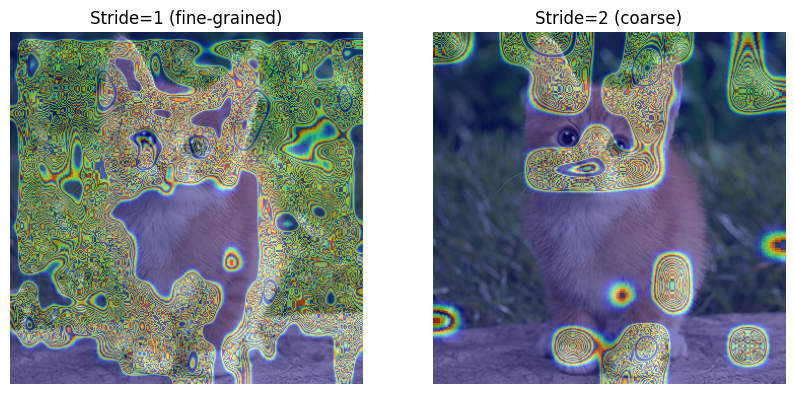

In [15]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import requests


# --------------------------------------------------
# 1️⃣ 두 모델 정의 (stride=1 vs stride=2)
# --------------------------------------------------
def get_resnet(stride_1=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if stride_1:
        model.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
    model.eval()
    return model

model_stride1 = get_resnet(stride_1=True)
model_stride2 = get_resnet(stride_1=False)


# --------------------------------------------------
# 2️⃣ 이미지 불러오기 & 전처리
# --------------------------------------------------
url = "https://pytorch.org/tutorials/_static/img/cat.jpg"  # 아무 이미지로 가능
# url = "https://www.nylabone.com/-/media/project/oneweb/nylabone/images/dog101/10-intelligent-dog-breeds/golden-retriever-tongue-out.jpg?h=430&w=710&hash=7FEB820D235A44B76B271060E03572C7"
img = Image.open(requests.get(url, stream=True).raw).convert('RGB')

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(img).unsqueeze(0)


# --------------------------------------------------
# 3️⃣ Grad-CAM 준비
# --------------------------------------------------
cam_stride1 = GradCAM(model_stride1, target_layer="layer3.0.conv2")
cam_stride2 = GradCAM(model_stride2, target_layer="layer3.0.conv2")

# --------------------------------------------------
# 4️⃣ CAM 계산
# --------------------------------------------------
out1 = model_stride1(input_tensor)
out2 = model_stride2(input_tensor)

idx1 = out1.squeeze(0).argmax().item()
idx2 = out2.squeeze(0).argmax().item()

activation_map_1 = cam_stride1(idx1, scores=out1)[0]
activation_map_2 = cam_stride2(idx2, scores=out2)[0]

# --------------------------------------------------
# 5️⃣ 시각화
# --------------------------------------------------
def visualize_heatmap(img, heatmap, title):
    result = overlay_mask(img, T.ToPILImage()(heatmap), alpha=0.5)
    plt.imshow(result)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
visualize_heatmap(img, activation_map_1, "Stride=1 (fine-grained)")
plt.subplot(1,2,2)
visualize_heatmap(img, activation_map_2, "Stride=2 (coarse)")
plt.show()

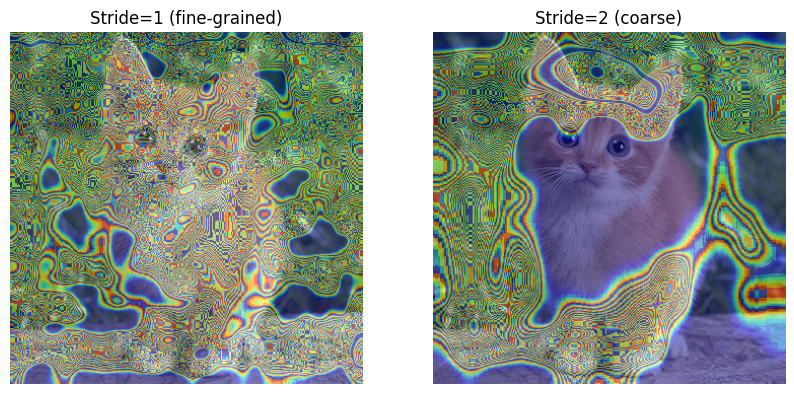

In [16]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import requests


# --------------------------------------------------
# 1️⃣ 두 모델 정의 (stride=1 vs stride=2)
# --------------------------------------------------
def get_resnet(stride_1=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if stride_1:
        model.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
    model.eval()
    return model

model_stride1 = get_resnet(stride_1=True)
model_stride2 = get_resnet(stride_1=False)


# --------------------------------------------------
# 2️⃣ 이미지 불러오기 & 전처리
# --------------------------------------------------
url = "https://pytorch.org/tutorials/_static/img/cat.jpg"  # 아무 이미지로 가능
# url = "https://www.nylabone.com/-/media/project/oneweb/nylabone/images/dog101/10-intelligent-dog-breeds/golden-retriever-tongue-out.jpg?h=430&w=710&hash=7FEB820D235A44B76B271060E03572C7"
img = Image.open(requests.get(url, stream=True).raw).convert('RGB')

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(img).unsqueeze(0)


# --------------------------------------------------
# 3️⃣ Grad-CAM 준비
# --------------------------------------------------
cam_stride1 = GradCAM(model_stride1, target_layer="layer3.1.conv2")
cam_stride2 = GradCAM(model_stride2, target_layer="layer3.1.conv2")

# --------------------------------------------------
# 4️⃣ CAM 계산
# --------------------------------------------------
out1 = model_stride1(input_tensor)
out2 = model_stride2(input_tensor)

idx1 = out1.squeeze(0).argmax().item()
idx2 = out2.squeeze(0).argmax().item()

activation_map_1 = cam_stride1(idx1, scores=out1)[0]
activation_map_2 = cam_stride2(idx2, scores=out2)[0]

# --------------------------------------------------
# 5️⃣ 시각화
# --------------------------------------------------
def visualize_heatmap(img, heatmap, title):
    result = overlay_mask(img, T.ToPILImage()(heatmap), alpha=0.5)
    plt.imshow(result)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
visualize_heatmap(img, activation_map_1, "Stride=1 (fine-grained)")
plt.subplot(1,2,2)
visualize_heatmap(img, activation_map_2, "Stride=2 (coarse)")
plt.show()

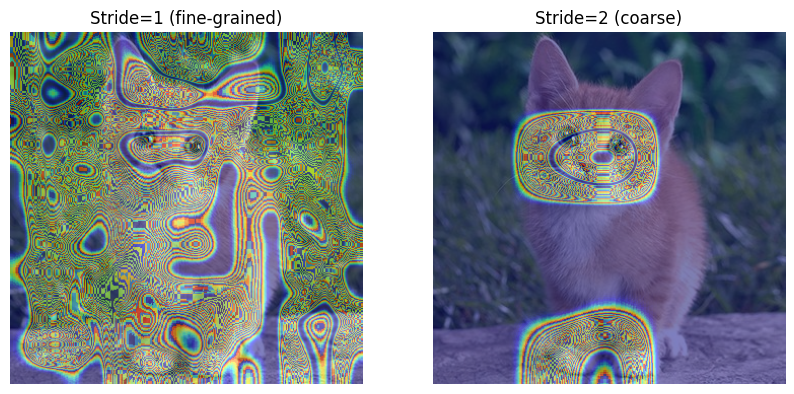

In [17]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import requests


# --------------------------------------------------
# 1️⃣ 두 모델 정의 (stride=1 vs stride=2)
# --------------------------------------------------
def get_resnet(stride_1=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if stride_1:
        model.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
    model.eval()
    return model

model_stride1 = get_resnet(stride_1=True)
model_stride2 = get_resnet(stride_1=False)


# --------------------------------------------------
# 2️⃣ 이미지 불러오기 & 전처리
# --------------------------------------------------
url = "https://pytorch.org/tutorials/_static/img/cat.jpg"  # 아무 이미지로 가능
# url = "https://www.nylabone.com/-/media/project/oneweb/nylabone/images/dog101/10-intelligent-dog-breeds/golden-retriever-tongue-out.jpg?h=430&w=710&hash=7FEB820D235A44B76B271060E03572C7"
img = Image.open(requests.get(url, stream=True).raw).convert('RGB')

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(img).unsqueeze(0)


# --------------------------------------------------
# 3️⃣ Grad-CAM 준비
# --------------------------------------------------
cam_stride1 = GradCAM(model_stride1, target_layer="layer4.0.conv2")
cam_stride2 = GradCAM(model_stride2, target_layer="layer4.0.conv2")

# --------------------------------------------------
# 4️⃣ CAM 계산
# --------------------------------------------------
out1 = model_stride1(input_tensor)
out2 = model_stride2(input_tensor)

idx1 = out1.squeeze(0).argmax().item()
idx2 = out2.squeeze(0).argmax().item()

activation_map_1 = cam_stride1(idx1, scores=out1)[0]
activation_map_2 = cam_stride2(idx2, scores=out2)[0]

# --------------------------------------------------
# 5️⃣ 시각화
# --------------------------------------------------
def visualize_heatmap(img, heatmap, title):
    result = overlay_mask(img, T.ToPILImage()(heatmap), alpha=0.5)
    plt.imshow(result)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
visualize_heatmap(img, activation_map_1, "Stride=1 (fine-grained)")
plt.subplot(1,2,2)
visualize_heatmap(img, activation_map_2, "Stride=2 (coarse)")
plt.show()

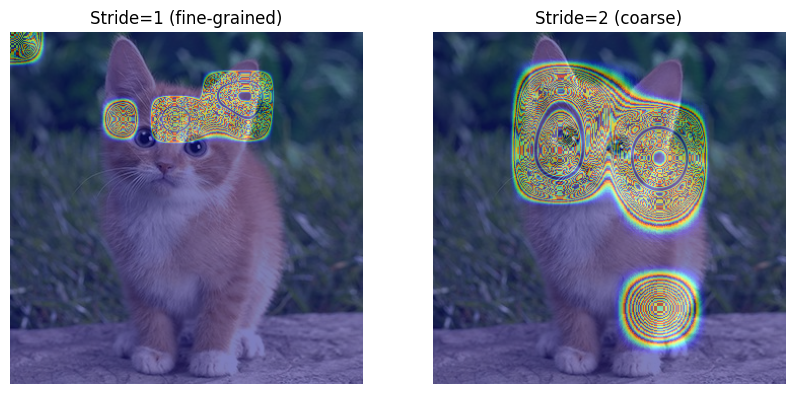

In [19]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import requests


# --------------------------------------------------
# 1️⃣ 두 모델 정의 (stride=1 vs stride=2)
# --------------------------------------------------
def get_resnet(stride_1=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if stride_1:
        model.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
    model.eval()
    return model

model_stride1 = get_resnet(stride_1=True)
model_stride2 = get_resnet(stride_1=False)


# --------------------------------------------------
# 2️⃣ 이미지 불러오기 & 전처리
# --------------------------------------------------
url = "https://pytorch.org/tutorials/_static/img/cat.jpg"  # 아무 이미지로 가능
# url = "https://www.nylabone.com/-/media/project/oneweb/nylabone/images/dog101/10-intelligent-dog-breeds/golden-retriever-tongue-out.jpg?h=430&w=710&hash=7FEB820D235A44B76B271060E03572C7"
img = Image.open(requests.get(url, stream=True).raw).convert('RGB')

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(img).unsqueeze(0)


# --------------------------------------------------
# 3️⃣ Grad-CAM 준비
# --------------------------------------------------
cam_stride1 = GradCAM(model_stride1, target_layer="layer4.1.conv1")
cam_stride2 = GradCAM(model_stride2, target_layer="layer4.1.conv1")

# --------------------------------------------------
# 4️⃣ CAM 계산
# --------------------------------------------------
out1 = model_stride1(input_tensor)
out2 = model_stride2(input_tensor)

idx1 = out1.squeeze(0).argmax().item()
idx2 = out2.squeeze(0).argmax().item()

activation_map_1 = cam_stride1(idx1, scores=out1)[0]
activation_map_2 = cam_stride2(idx2, scores=out2)[0]

# --------------------------------------------------
# 5️⃣ 시각화
# --------------------------------------------------
def visualize_heatmap(img, heatmap, title):
    result = overlay_mask(img, T.ToPILImage()(heatmap), alpha=0.5)
    plt.imshow(result)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
visualize_heatmap(img, activation_map_1, "Stride=1 (fine-grained)")
plt.subplot(1,2,2)
visualize_heatmap(img, activation_map_2, "Stride=2 (coarse)")
plt.show()

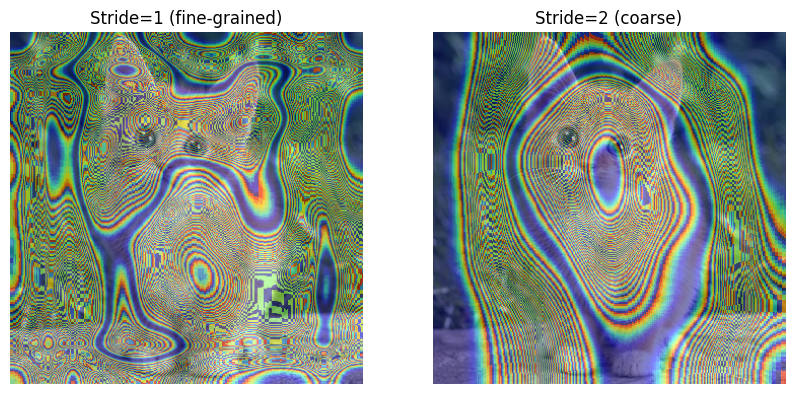

In [18]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import requests


# --------------------------------------------------
# 1️⃣ 두 모델 정의 (stride=1 vs stride=2)
# --------------------------------------------------
def get_resnet(stride_1=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if stride_1:
        model.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
    model.eval()
    return model

model_stride1 = get_resnet(stride_1=True)
model_stride2 = get_resnet(stride_1=False)


# --------------------------------------------------
# 2️⃣ 이미지 불러오기 & 전처리
# --------------------------------------------------
url = "https://pytorch.org/tutorials/_static/img/cat.jpg"  # 아무 이미지로 가능
# url = "https://www.nylabone.com/-/media/project/oneweb/nylabone/images/dog101/10-intelligent-dog-breeds/golden-retriever-tongue-out.jpg?h=430&w=710&hash=7FEB820D235A44B76B271060E03572C7"
img = Image.open(requests.get(url, stream=True).raw).convert('RGB')

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

input_tensor = transform(img).unsqueeze(0)


# --------------------------------------------------
# 3️⃣ Grad-CAM 준비
# --------------------------------------------------
cam_stride1 = GradCAM(model_stride1, target_layer="layer4.1.conv2")
cam_stride2 = GradCAM(model_stride2, target_layer="layer4.1.conv2")

# --------------------------------------------------
# 4️⃣ CAM 계산
# --------------------------------------------------
out1 = model_stride1(input_tensor)
out2 = model_stride2(input_tensor)

idx1 = out1.squeeze(0).argmax().item()
idx2 = out2.squeeze(0).argmax().item()

activation_map_1 = cam_stride1(idx1, scores=out1)[0]
activation_map_2 = cam_stride2(idx2, scores=out2)[0]

# --------------------------------------------------
# 5️⃣ 시각화
# --------------------------------------------------
def visualize_heatmap(img, heatmap, title):
    result = overlay_mask(img, T.ToPILImage()(heatmap), alpha=0.5)
    plt.imshow(result)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
visualize_heatmap(img, activation_map_1, "Stride=1 (fine-grained)")
plt.subplot(1,2,2)
visualize_heatmap(img, activation_map_2, "Stride=2 (coarse)")
plt.show()